# 1.0 Load Prepared Dataset

- Load the combined 2025 order-level dataset created from the four cleaned quarterly files.
- Validate dataset structure and confirm the file is ready for Workbook 9 analysis.
- Confirm row count and available columns before building segmentation metrics.
- Establish this dataset as the base table for order behavior and repeat pattern analysis.
-  Dataset contains one row per order.
- No customer identifier is available; analysis focuses on order-level behavior.

In [1]:
import pandas as pd

orders = pd.read_csv('../data/cleaned/orders_2025_full.csv')

display(orders.head())
print('Shape:', orders.shape)
print('\nColumns:')
print(orders.columns.tolist())

,Order Date,Order ID,Order Type,Tax Amount,Tip,Discount,Order Total,Payments Total,Tender
0,2025-03-31 22:54:00-07:00,QQBMWE3NMZQ0Y,Pick Up,2.09,0.00,0.0,25.99,25.99,Cash
1,2025-03-31 22:35:00-07:00,TH041BMRDC2Y6,Delivery,0.00,0.00,0.0,25.13,0.00,NaN
2,2025-03-31 22:33:00-07:00,06KJV691ZMV48,Pick Up,1.44,3.29,0.0,17.90,17.90,Debit Card
3,2025-03-31 22:24:00-07:00,ASKA2CPN7GT2A,Pick Up,3.27,0.00,0.0,40.69,40.69,Cash
4,2025-03-31 22:23:00-07:00,GK5Z5D128NA1M,Pick Up,1.61,0.92,0.0,20.05,20.05,Credit Card


Shape: (50487, 9)

Columns:
['Order Date', 'Order ID', 'Order Type', 'Tax Amount', 'Tip', 'Discount', 'Order Total', 'Payments Total', 'Tender']


# 1.1 Define Segmentation Base Columns

- Select only the required fields for order behavior analysis.
- Standardize column names for consistency and easier downstream calculations.
- Define the core analytical fields:
  - Order identifier
  - Order timestamp
  - Revenue metric
  - Discount metric
- Ensure correct data types for time-based analysis.
- Create a working dataset specifically for segmentation.

In [3]:
# Select relevant columns
orders_base = orders[[
    'Order ID',
    'Order Date',
    'Order Total',
    'Discount'
]].copy()

# Standardize column names
orders_base.columns = [
    'order_id',
    'order_datetime',
    'order_total',
    'discount_amount'
]

# Convert datetime
orders_base['order_datetime'] = pd.to_datetime(orders_base['order_datetime'], utc=True)

# Preview
display(orders_base.head())
print('Shape:', orders_base.shape)

,order_id,order_datetime,order_total,discount_amount
0,QQBMWE3NMZQ0Y,2025-04-01 05:54:00+00:00,25.99,0.0
1,TH041BMRDC2Y6,2025-04-01 05:35:00+00:00,25.13,0.0
2,06KJV691ZMV48,2025-04-01 05:33:00+00:00,17.90,0.0
3,ASKA2CPN7GT2A,2025-04-01 05:24:00+00:00,40.69,0.0
4,GK5Z5D128NA1M,2025-04-01 05:23:00+00:00,20.05,0.0


Shape: (50487, 4)


# 2.0 Build Order-Level Summary Table

- Aggregate dataset to one row per order for behavioral analysis.
- Validate that each order_id is unique and represents a single transaction.
- Compute core order-level metrics:
  - Order revenue
  - Discount amount
- Establish this table as the foundation for segmentation and downstream analysis.

In [4]:
# Aggregate to one row per order
order_summary = (
    orders_base
    .groupby('order_id', as_index=False)
    .agg({
        'order_datetime': 'min',
        'order_total': 'sum',
        'discount_amount': 'sum'
    })
)

# Validate uniqueness
print('Unique orders:', order_summary['order_id'].nunique())
print('Total rows:', len(order_summary))

# Preview
display(order_summary.head())

Unique orders: 50487
Total rows: 50487


,order_id,order_datetime,order_total,discount_amount
0,000PSET66ZWQW,2025-06-14 02:52:00+00:00,38.79,0.0
1,0013K8553R7VM,2025-05-29 02:16:00+00:00,59.99,0.0
2,001R8NCAXBCRP,2025-09-30 20:28:00+00:00,5.40,0.0
3,002M65M3GXWRT,2025-06-13 18:25:00+00:00,12.84,0.0
4,002M9K3P5RDJ8,2025-07-30 00:46:00+00:00,0.00,0.0


# 2.1 Validate Order-Level Metrics

- Verify data integrity after aggregation.
- Check for:
  - Missing values
  - Negative or zero revenue orders
  - Abnormal discount values
- Review distribution of key metrics:
  - Order revenue
  - Discount amount
- Ensure dataset is reliable before segmentation analysis.

In [5]:
# Check nulls
print(order_summary.isnull().sum())

# Basic stats
display(order_summary[['order_total', 'discount_amount']].describe())

# Check for negative or zero values
print('Zero or negative revenue orders:', (order_summary['order_total'] <= 0).sum())
print('Negative discounts:', (order_summary['discount_amount'] < 0).sum())

order_id           0
order_datetime     0
order_total        0
discount_amount    0
dtype: int64


,order_total,discount_amount
count,50487.000000,50487.000000
mean,30.696161,-0.270368
std,26.648298,7.322725
min,0.000000,-948.080000
25%,16.950000,0.000000
50%,29.170000,0.000000
75%,39.530000,0.000000
max,1423.540000,0.000000


Zero or negative revenue orders: 1947
Negative discounts: 931


# 2.2 Create Time-Based Features

- Extract time-based features from order_datetime.
- Convert timestamps from UTC to local time for accurate business interpretation.
- Create features for:
  - Hour of day
  - Day of week
  - Calendar date
  - Weekend indicator
- These features will support demand pattern and segmentation analysis.

In [6]:
# Convert to local timezone (Pacific Time)
order_summary['order_datetime'] = order_summary['order_datetime'].dt.tz_convert('US/Pacific')

# Create time features
order_summary['order_hour'] = order_summary['order_datetime'].dt.hour
order_summary['order_dow'] = order_summary['order_datetime'].dt.dayofweek
order_summary['order_date'] = order_summary['order_datetime'].dt.date
order_summary['is_weekend'] = order_summary['order_dow'].isin([5, 6])

# Preview
display(order_summary.head())

,order_id,order_datetime,order_total,discount_amount,order_hour,order_dow,order_date,is_weekend
0,000PSET66ZWQW,2025-06-13 19:52:00-07:00,38.79,0.0,19,4,2025-06-13,False
1,0013K8553R7VM,2025-05-28 19:16:00-07:00,59.99,0.0,19,2,2025-05-28,False
2,001R8NCAXBCRP,2025-09-30 13:28:00-07:00,5.40,0.0,13,1,2025-09-30,False
3,002M65M3GXWRT,2025-06-13 11:25:00-07:00,12.84,0.0,11,4,2025-06-13,False
4,002M9K3P5RDJ8,2025-07-29 17:46:00-07:00,0.00,0.0,17,1,2025-07-29,False


# 3.0 Order Revenue Distribution Analysis

- Analyze how order revenue is distributed across all transactions.
- Identify whether revenue is driven by many small orders or fewer high-value orders.
- Evaluate spread and skewness of order values.
- Establish baseline understanding of order value behavior before segmentation.

In [7]:
# Summary statistics
display(order_summary['order_total'].describe())

# Percentiles for deeper distribution insight
percentiles = order_summary['order_total'].quantile([0.25, 0.5, 0.75, 0.9, 0.95])
print(percentiles)

count    50487.000000
mean        30.696161
std         26.648298
min          0.000000
25%         16.950000
50%         29.170000
75%         39.530000
max       1423.540000
Name: order_total, dtype: float64

0.25    16.950
0.50    29.170
0.75    39.530
0.90    54.128
0.95    66.084
Name: order_total, dtype: float64


## 3.1 Order Revenue Distribution Visualization

- Visualize distribution of order values.
- Identify skewness and presence of outliers.
- Support segmentation threshold decisions with visual evidence.

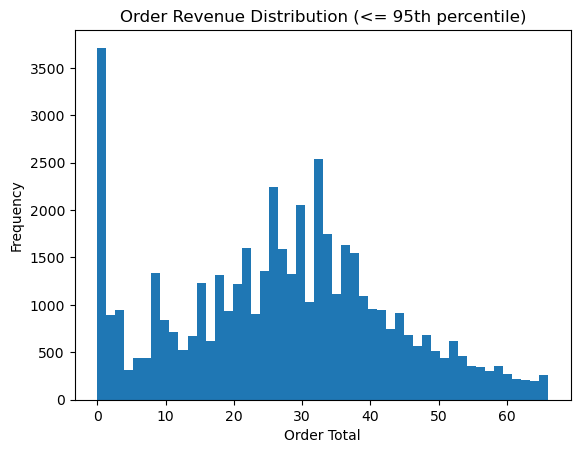

In [10]:
import matplotlib.pyplot as plt

# Calculate upper bound (95th percentile)
upper_bound = order_summary['order_total'].quantile(0.95)

# Filter data
filtered_orders = order_summary[order_summary['order_total'] <= upper_bound]

# Plot histogram
import matplotlib.pyplot as plt

plt.figure()
plt.hist(filtered_orders['order_total'], bins=50)
plt.title('Order Revenue Distribution (<= 95th percentile)')
plt.xlabel('Order Total')
plt.ylabel('Frequency')
plt.show()

## 3.2 Order Revenue Distribution (Log Scale)

- Visualize full distribution using log transformation.
- Helps reveal structure across both small and large orders.

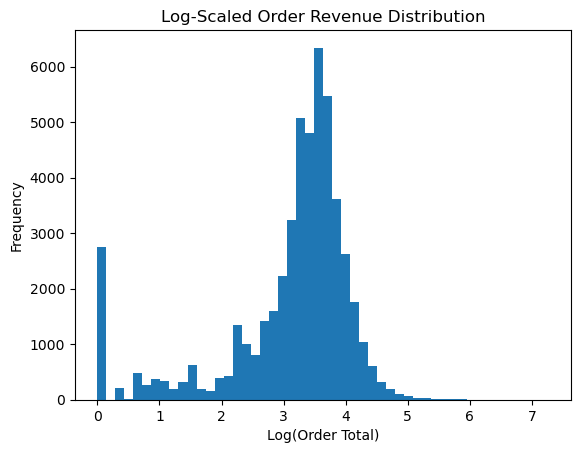

In [11]:
import numpy as np

plt.figure()
plt.hist(np.log1p(order_summary['order_total']), bins=50)
plt.title('Log-Scaled Order Revenue Distribution')
plt.xlabel('Log(Order Total)')
plt.ylabel('Frequency')
plt.show()

## 3.3 Identify High-Value Order Thresholds

- Define thresholds for segmenting orders into value tiers.
- Use percentiles to establish:
  - Low-value orders
  - Mid-value orders
  - High-value orders
- Prepare for segmentation labeling in the next section.

In [9]:
# Define thresholds
q50 = order_summary['order_total'].quantile(0.5)
q75 = order_summary['order_total'].quantile(0.75)
q90 = order_summary['order_total'].quantile(0.9)

print('Median (50th percentile):', q50)
print('75th percentile:', q75)
print('90th percentile:', q90)

Median (50th percentile): 29.17
75th percentile: 39.53
90th percentile: 54.12800000000003


# 4.0 Order Value Segmentation

- Segment orders into value tiers based on revenue thresholds.
- Use percentile-based cutoffs to define:
  - Low-value orders
  - Mid-value orders
  - High-value orders
- Assign each order to a segment for downstream analysis.
- Enable comparison of revenue contribution across segments.

In [16]:
# Define thresholds
q50 = order_summary['order_total'].quantile(0.5)
q75 = order_summary['order_total'].quantile(0.75)
q90 = order_summary['order_total'].quantile(0.9)

# Create segmentation function
def assign_order_segment(x):
    if x <= q50:
        return 'Low'
    elif x <= q75:
        return 'Mid'
    elif x <= q90:
        return 'High'
    else:
        return 'Very High'

# Apply segmentation
order_summary['order_segment'] = order_summary['order_total'].apply(assign_order_segment)

# Preview
display(order_summary.head())

,order_id,order_datetime,order_total,discount_amount,order_hour,order_dow,order_date,is_weekend,order_segment
0,000PSET66ZWQW,2025-06-13 19:52:00-07:00,38.79,0.0,19,4,2025-06-13,False,Mid
1,0013K8553R7VM,2025-05-28 19:16:00-07:00,59.99,0.0,19,2,2025-05-28,False,Very High
2,001R8NCAXBCRP,2025-09-30 13:28:00-07:00,5.40,0.0,13,1,2025-09-30,False,Low
3,002M65M3GXWRT,2025-06-13 11:25:00-07:00,12.84,0.0,11,4,2025-06-13,False,Low
4,002M9K3P5RDJ8,2025-07-29 17:46:00-07:00,0.00,0.0,17,1,2025-07-29,False,Low


## 4.1 Segment Distribution

- Analyze the number of orders in each value segment.
- Understand how orders are distributed across tiers.
- Identify whether most orders are low-value or concentrated in higher tiers.

In [17]:
# Count of orders by segment
segment_counts = order_summary['order_segment'].value_counts()

print(segment_counts)

order_segment
Low          25244
Mid          12636
High          7558
Very High     5049
Name: count, dtype: int64


## 4.2 Revenue Contribution by Segment

- Calculate total revenue generated by each segment.
- Compare contribution of each segment to overall revenue.
- Identify which segments drive the majority of revenue.

In [18]:
# Revenue by segment
segment_revenue = (
    order_summary
    .groupby('order_segment')['order_total']
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

order_segment
Mid          429959.23
Very High    391110.98
Low          382198.85
High         346488.03
Name: order_total, dtype: float64


## 4.3 Segment Share of Total Revenue

- Convert revenue by segment into percentage of total revenue.
- Highlight disproportionate contribution from high-value segments.

In [19]:
# Percentage contribution
segment_share = segment_revenue / segment_revenue.sum()

print(segment_share)

order_segment
Mid          0.277437
Very High    0.252369
Low          0.246619
High         0.223576
Name: order_total, dtype: float64


# 5.0 Revenue Concentration Analysis

- Analyze how revenue is distributed across orders.
- Identify whether a small percentage of orders drive a large share of revenue.
- Rank orders by value to evaluate concentration effects.
- Establish foundation for Pareto-style analysis (80/20 behavior).

In [20]:
# Sort orders by value (descending)
order_summary_sorted = order_summary.sort_values(by='order_total', ascending=False).reset_index(drop=True)

# Compute cumulative revenue
order_summary_sorted['cumulative_revenue'] = order_summary_sorted['order_total'].cumsum()

# Compute total revenue
total_revenue = order_summary_sorted['order_total'].sum()

# Compute cumulative revenue percentage
order_summary_sorted['cumulative_revenue_pct'] = order_summary_sorted['cumulative_revenue'] / total_revenue

# Compute order percentage index
order_summary_sorted['order_rank_pct'] = (order_summary_sorted.index + 1) / len(order_summary_sorted)

# Preview
display(order_summary_sorted.head())

,order_id,order_datetime,order_total,discount_amount,order_hour,order_dow,order_date,is_weekend,order_segment,cumulative_revenue,cumulative_revenue_pct,order_rank_pct
0,2YAWWPVBYK2T8,2025-10-30 22:06:00-07:00,1423.54,0.00,22,3,2025-10-30,False,Very High,1423.54,0.000919,0.000020
1,30G4MX9390JS8,2025-05-24 15:17:00-07:00,1234.55,0.00,15,5,2025-05-24,True,Very High,2658.09,0.001715,0.000040
2,4PTPS43C57WJR,2025-05-24 15:31:00-07:00,1234.55,0.00,15,5,2025-05-24,True,Very High,3892.64,0.002512,0.000059
3,C258DPFE8TF08,2025-09-12 14:10:00-07:00,1047.26,0.00,14,4,2025-09-12,False,Very High,4939.90,0.003188,0.000079
4,XQPHNMD0ZR9VM,2025-03-30 21:32:00-07:00,1031.04,-948.08,21,6,2025-03-30,True,Very High,5970.94,0.003853,0.000099


## 5.1 Pareto Distribution Visualization

- Visualize cumulative revenue contribution by order percentage.
- Identify whether revenue follows an 80/20 distribution.
- Highlight how quickly revenue accumulates across top orders.

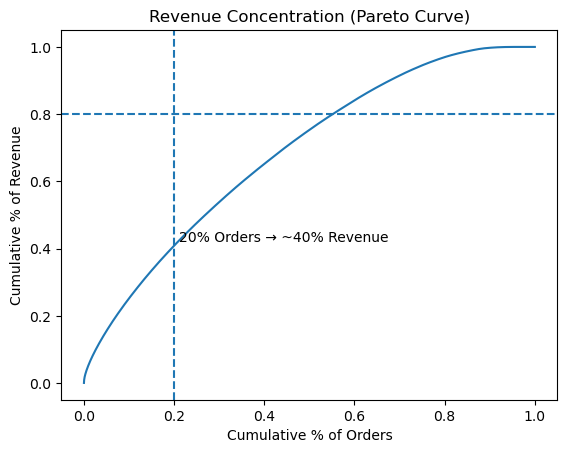

In [46]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(order_summary_sorted['order_rank_pct'], order_summary_sorted['cumulative_revenue_pct'])

plt.axhline(0.8, linestyle='--')
plt.axvline(0.2, linestyle='--')

plt.title('Revenue Concentration (Pareto Curve)')
plt.xlabel('Cumulative % of Orders')
plt.ylabel('Cumulative % of Revenue')

plt.text(0.21, 0.42, '20% Orders → ~40% Revenue')

plt.show()

## 5.2 Top Order Contribution Analysis

- Quantify how much revenue is generated by top segments of orders.
- Evaluate:
  - Top 10% of orders
  - Top 20% of orders
  - Top 30% of orders
- Compare their contribution to total revenue.

In [22]:
# Top X% revenue contribution
top_10 = order_summary_sorted[order_summary_sorted['order_rank_pct'] <= 0.10]['order_total'].sum() / total_revenue
top_20 = order_summary_sorted[order_summary_sorted['order_rank_pct'] <= 0.20]['order_total'].sum() / total_revenue
top_30 = order_summary_sorted[order_summary_sorted['order_rank_pct'] <= 0.30]['order_total'].sum() / total_revenue

print('Top 10% revenue share:', round(top_10 * 100, 2), '%')
print('Top 20% revenue share:', round(top_20 * 100, 2), '%')
print('Top 30% revenue share:', round(top_30 * 100, 2), '%')

Top 10% revenue share: 25.23 %
Top 20% revenue share: 40.91 %
Top 30% revenue share: 53.87 %


## 5.3 Revenue Concentration Interpretation

- Interpret whether revenue is concentrated among a small subset of orders.
- Identify if business performance depends heavily on high-value transactions.
- Assess risk:
  - High concentration → reliance on fewer large orders
  - Low concentration → stable, broad-based demand
- Prepare insight for strategic recommendations.
- Revenue does not follow a strict 80/20 distribution, indicating a more evenly distributed revenue base.

# 6.0 Order Segment Behavior Analysis

- Analyze how different order value segments behave across time.
- Identify when high-value vs low-value orders occur.
- Compare temporal patterns to uncover operational and revenue opportunities.
- Connect order segments to demand patterns (hourly and weekly).

In [24]:
# Orders by segment and hour
segment_hour = (
    order_summary
    .groupby(['order_segment', 'order_hour'])
    .size()
    .reset_index(name='order_count')
)

display(segment_hour.head())

,order_segment,order_hour,order_count
0,High,9,1
1,High,10,33
2,High,11,328
3,High,12,315
4,High,13,346


## 6.1 Order Distribution by Hour and Segment

- Analyze distribution of orders by hour across value segments.
- Identify peak hours for:
  - High-value orders
  - Low-value orders
- Detect whether premium orders cluster at specific times of day.

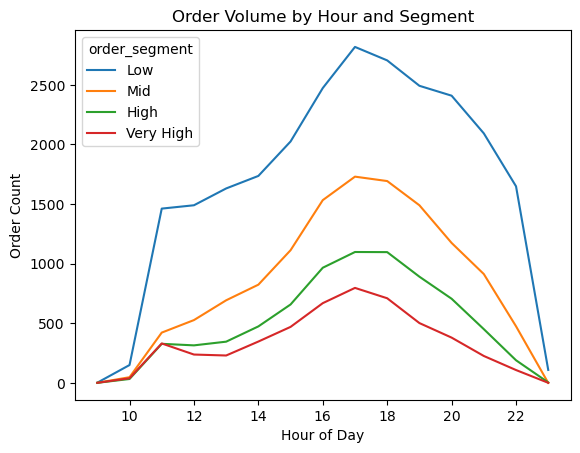

In [35]:
# Pivot for visualization
pivot_hour = segment_hour.pivot(index='order_hour', columns='order_segment', values='order_count').fillna(0)

# Define order
order = ['Low', 'Mid', 'High', 'Very High']

# Reorder columns
pivot_hour = pivot_hour[order]

# Plot
pivot_hour.plot()

plt.title('Order Volume by Hour and Segment')
plt.xlabel('Hour of Day')
plt.ylabel('Order Count')

plt.show()

## 6.2 Order Distribution by Day of Week

- Analyze how order segments vary across days of the week.
- Identify whether higher-value orders occur on weekends or weekdays.
- Evaluate demand patterns by segment across the week.

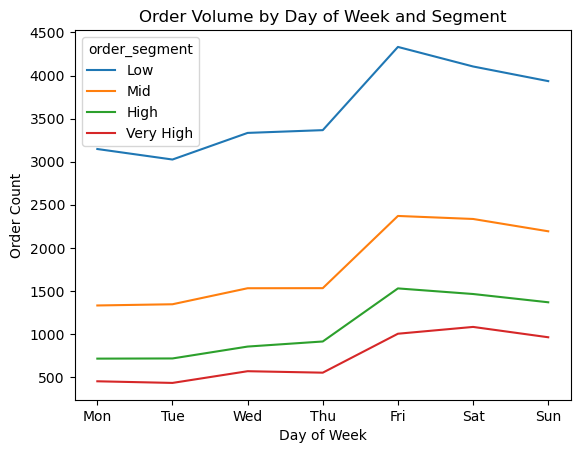

In [45]:
segment_dow = (
    order_summary
    .groupby(['order_segment', 'order_dow'])
    .size()
    .reset_index(name='order_count')
)

# Pivot
pivot_dow = segment_dow.pivot(index='order_dow', columns='order_segment', values='order_count').fillna(0)

# Rename index
pivot_dow.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Reorder columns
order = ['Low', 'Mid', 'High', 'Very High']
pivot_dow = pivot_dow[[col for col in order if col in pivot_dow.columns]]

# Plot
pivot_dow.plot()

plt.title('Order Volume by Day of Week and Segment')
plt.xlabel('Day of Week')
plt.ylabel('Order Count')

plt.show()

## 6.3 Revenue by Segment Over Time

- Analyze how revenue contribution varies by segment across time.
- Identify when high-value segments contribute most to total revenue.
- Support operational decisions (staffing, promotions, upselling).
- Revenue patterns closely mirror order volume patterns, reinforcing that demand timing drives revenue performance.

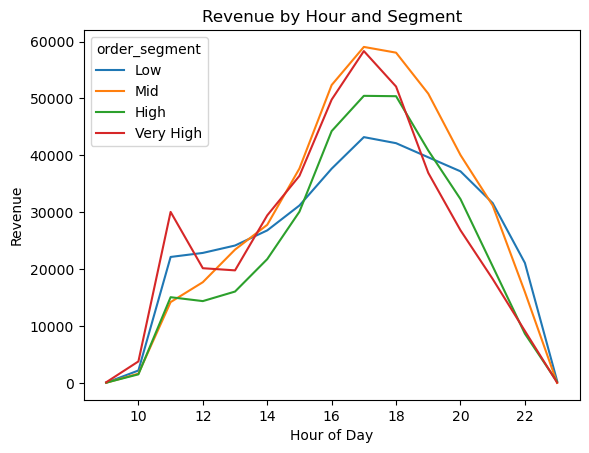

In [43]:
# Revenue by segment and hour
segment_hour_revenue = (
    order_summary
    .groupby(['order_segment', 'order_hour'])['order_total']
    .sum()
    .reset_index()
)

# Pivot
pivot_hour_rev = segment_hour_revenue.pivot(index='order_hour', columns='order_segment', values='order_total').fillna(0)

# Reorder Columns
order = ['Low', 'Mid', 'High', 'Very High']
pivot_hour_rev = pivot_hour_rev[[col for col in order if col in pivot_hour_rev.columns]]

# Plot
pivot_hour_rev.plot()

plt.title('Revenue by Hour and Segment')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue')

plt.show()

# 7.0 Executive Interpretation — Order Behavior Model

- Summarize how order behavior drives overall revenue performance.
- Identify the primary drivers of revenue based on prior analysis.
- Connect distribution, segmentation, and time-based behavior into a unified model.
- Establish a clear understanding of how the business generates revenue.

## 7.1 Revenue Structure Insight

- Revenue is broadly distributed across orders rather than concentrated in a small subset.
- Pareto analysis shows that top orders do not dominate total revenue.
- Business performance is supported by a wide base of transactions.
- Indicates a stable and diversified revenue structure.

## 7.2 Demand-Driven Behavior

- Order volume and revenue follow consistent time-based patterns.
- Peak activity occurs during evening hours (approximately 5–6 PM).
- End-of-week periods (Friday through Sunday) show the highest demand.
- Patterns are consistent across all order value segments.
- Indicates that demand timing is the primary driver of performance.

## 7.3 Order Value Dynamics

- Mid-value orders contribute the largest share of total revenue.
- High-value and very high-value orders are less consistent and less dominant.
- Low-value orders contribute significantly to volume but less to revenue.
- Business relies on a balance of volume and moderate order sizes.

## 7.4 Key Business Model Conclusion

- Revenue is driven by:
  - High transaction volume
  - Moderate order values
  - Peak demand timing
- The business does not rely on:
  - A small number of high-value orders
  - Isolated premium customer behavior
- Growth opportunities are tied to improving performance within existing demand patterns.

## 7.5 Strategic Implications — Revenue Growth Levers

- Translate analytical findings into actionable business strategies.
- Identify the most effective levers for increasing revenue based on observed behavior.

## 7.6 Peak Hour Optimization

- Focus operational efficiency during peak hours (5–6 PM).
- Ensure staffing levels match demand intensity.
- Reduce wait times and improve order throughput.
- Maximize order completion during high-volume periods.

## 7.7 Average Order Value Expansion

- Increase revenue by raising average order size rather than relying on higher order counts.
- Introduce:
  - Bundles and combo offers
  - Add-on recommendations (e.g., sides, drinks)
- Focus on mid-value order segment as the primary growth driver.

## 7.8 Weekend Revenue Maximization

- Leverage strong demand from Friday through Sunday.
- Deploy targeted promotions and upselling strategies during these periods.
- Align staffing, inventory, and marketing efforts with weekend demand patterns.

## 7.9 Weekday Demand Stimulation

- Address relatively lower weekday demand.
- Introduce:
  - Discounts
  - Limited-time offers
  - Loyalty incentives
- Aim to smooth demand across the week.

## 7.10 Discount Strategy Optimization

- Evaluate the role of discounts in driving order volume.
- Avoid over-reliance on discounts for revenue generation.
- Align discount usage with strategic goals:
  - Weekday demand stimulation
  - Customer acquisition (if applicable)

## 7.11 Executive Summary — Order Behavior Segmentation

- Order behavior is primarily driven by time-based demand patterns rather than customer-specific factors.
- Revenue is broadly distributed, with no extreme concentration among high-value orders.
- Mid-value orders represent the core revenue engine.
- Peak hours and weekends are the most critical periods for revenue generation.
- Growth opportunities lie in optimizing average order value and maximizing performance during high-demand windows.

# 8.0 Visualization Summary

- Present key visual insights from the analysis in a concise, executive-friendly format.
- Highlight the most important patterns:
  - Order value distribution
  - Revenue concentration
  - Time-based demand behavior
- Support strategic conclusions with clear visual evidence.

## 8.1 Order Revenue Distribution (Filtered)

- Visualize core order value distribution excluding extreme outliers.
- Focus on the range where the majority of transactions occur.
- Reinforce right-skewed nature of order values.

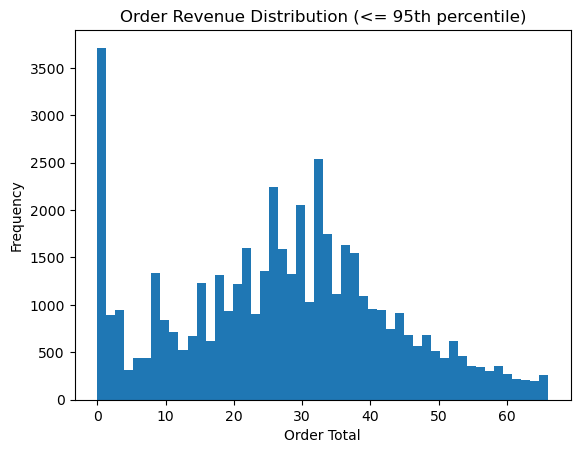

In [39]:
# 95th percentile filter
upper_bound = order_summary['order_total'].quantile(0.95)
filtered_orders = order_summary[order_summary['order_total'] <= upper_bound]

plt.figure()
plt.hist(filtered_orders['order_total'], bins=50)

plt.title('Order Revenue Distribution (<= 95th percentile)')
plt.xlabel('Order Total')
plt.ylabel('Frequency')

plt.show()

## 8.2 Revenue Concentration (Pareto Curve)

- Visualize cumulative revenue contribution across orders.
- Evaluate whether revenue is concentrated among top orders.
- Support conclusion regarding distributed revenue structure.

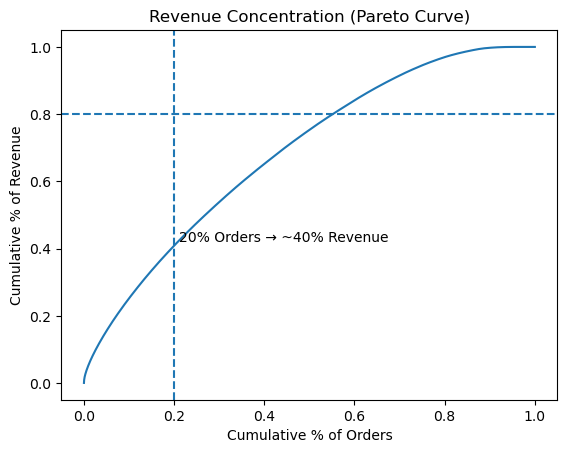

In [44]:
plt.figure()

plt.plot(order_summary_sorted['order_rank_pct'], order_summary_sorted['cumulative_revenue_pct'])

plt.axhline(0.8, linestyle='--')
plt.axvline(0.2, linestyle='--')

# Annotation
plt.text(0.21, 0.42, '20% Orders → ~40% Revenue')

plt.title('Revenue Concentration (Pareto Curve)')
plt.xlabel('Cumulative % of Orders')
plt.ylabel('Cumulative % of Revenue')

plt.show()

## 8.3 Revenue by Hour and Segment

- Visualize how revenue varies across time and order value segments.
- Highlight peak revenue hours and dominant segments.
- Reinforce importance of mid-value orders and peak demand windows.

<Figure size 640x480 with 0 Axes>

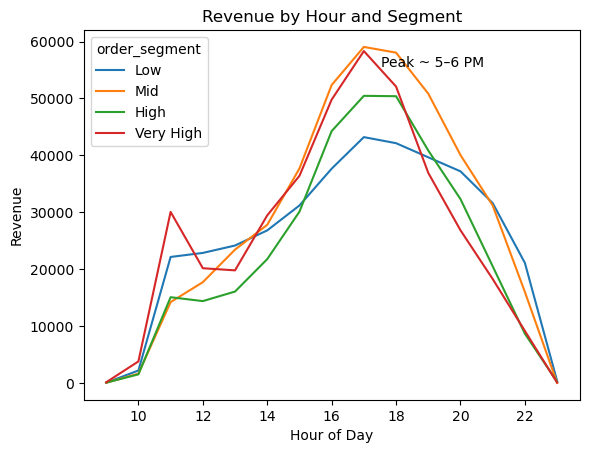

In [50]:
# Ensure column order
order = ['Low', 'Mid', 'High', 'Very High']
pivot_hour_rev = pivot_hour_rev[[col for col in order if col in pivot_hour_rev.columns]]

plt.figure()
pivot_hour_rev.plot()

plt.title('Revenue by Hour and Segment')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue')

# Clean annotation
plt.text(0.6, 0.9, 'Peak ~ 5–6 PM', transform=plt.gca().transAxes)

plt.show()